# Data Correctness

This notebook provides the data correctness validation executed on **IberFire**. The following was verified:

1. A temporal consistency check
2. Visual inspection (see notebook `1.2-Visualisation-of-IberFire.ipynb`)
3. Categorical and binary feature check
4. Proportion-based variable check
5. Percentage-based variable check
6. Missing value check on spatial-only data

In [ ]:
from src.config import DATACUBE_PATH
import xarray as xr
import pandas as pd
import numpy as np

ds = xr.open_dataset(DATACUBE_PATH)

## 1. Temporal consistency check

In [ ]:
time_values = ds['time'].values
has_duplicates = len(time_values) != len(np.unique(time_values))

print("Has duplicated time coordinates:", has_duplicates)

Has duplicated time coordinates: False


In [6]:
expected_range = pd.date_range(start="2007-12-01", end="2024-12-31", freq='D')
missing_dates = set(expected_range) - set(pd.to_datetime(ds['time'].values))

print(f"Missing dates: {len(missing_dates)}")

Missing dates: 0


## 2. Visual inspection

The visual inspection can be found on the `1.2-Visualisation-of-IberFire.ipynb` notebook.

## 3. Categorical and binary feature check

#### AutonomousCommunities

In [7]:
feature = ds["AutonomousCommunities"]
in_range = ((feature >= 0) & (feature <= 17) & (feature == feature.astype(int))).all()
print("Values are integers in [0, 17]:", bool(in_range))

Values are integers in [0, 17]: True


#### Binary features

In [8]:
features = ["is_spain", 
            "is_sea",
            "is_waterbody",
            "is_holiday",
            "is_natura2000",
            "is_fire",
            "is_near_fire"]

for feature in features:
    data = ds[feature].values
    is_binary = ((data == 0) | (data == 1)).all()

    print(f"Feature {feature} is binary: {is_binary}")

Feature is_spain is binary: True
Feature is_sea is binary: True
Feature is_waterbody is binary: True
Feature is_holiday is binary: True
Feature is_natura2000 is binary: True
Feature is_fire is binary: True
Feature is_near_fire is binary: True


## 4. Proportion-based variable checks

#### Corine Land Cover: Hierarchy level 3

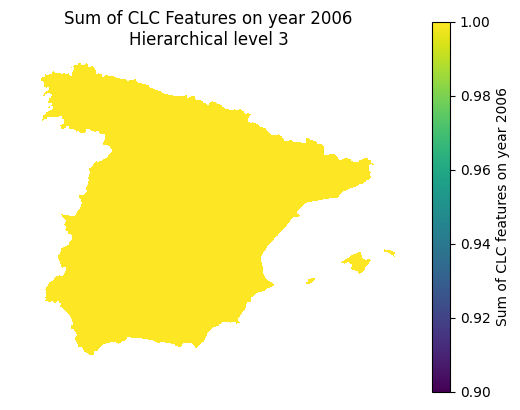

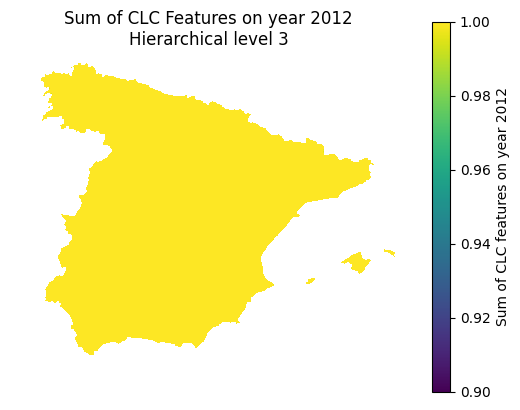

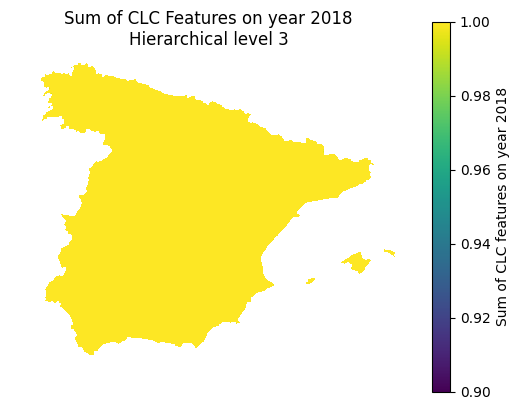

In [9]:
import numpy as np
import matplotlib.pyplot as plt

for year in ["2006", "2012", "2018"]:
    clc_subset = ds[[f"CLC_{year}_{i}" for i in range(1,45)]]

    # Clip to valid instances (is_spain == 1)
    clc_subset = clc_subset.where(ds["is_spain"] == 1)


    arrays = []
    for var in clc_subset.data_vars:
        arrays.append(clc_subset[var].values)

    sum_array = np.sum(np.stack(arrays), axis=0)

    plt.imshow(sum_array, cmap='viridis', vmin = 0.9)  # You can use 'gray', 'plasma', etc. too
    plt.colorbar(label=f'Sum of CLC features on year {year}')
    plt.title(f'Sum of CLC Features on year {year}\nHierarchical level 3')
    plt.axis("off")
    plt.show()

#### Corine Land Cover: Hierarchy level 2

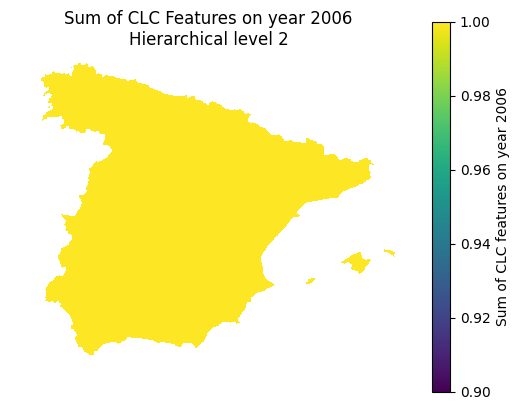

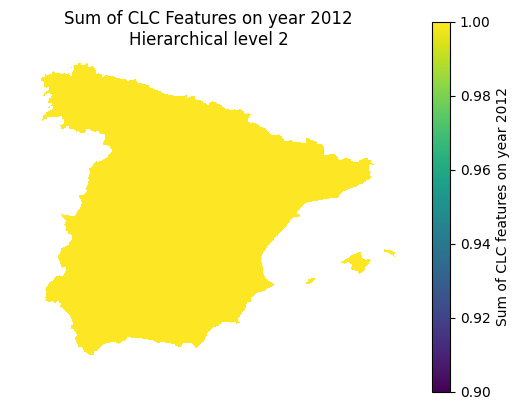

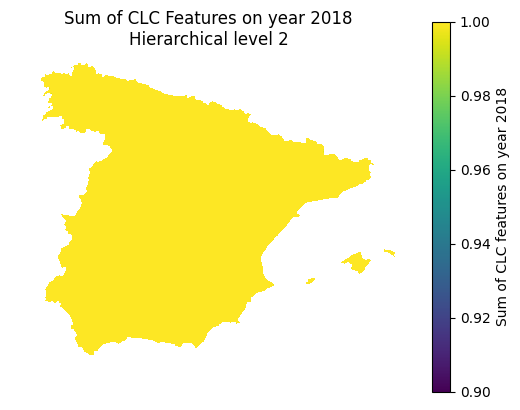

In [10]:
import numpy as np
import matplotlib.pyplot as plt

cases = ["urban_fabric_proportion",
        "industrial_proportion",
        "mine_proportion",
        "artificial_vegetation_proportion",
        "arable_land_proportion",
        "permanent_crops_proportion",
        "heterogeneous_agriculture_proportion",
        "forest_proportion",
        "scrub_proportion",
        "open_space_proportion",
        "inland_wetlands_proportion",
        "maritime_wetlands_proportion",
        "inland_waters_proportion",
        "marine_waters_proportion",
        "18"]

for year in ["2006", "2012", "2018"]:
    clc_subset = ds[[f"CLC_{year}_{case}" for case in cases]]

    # Clip to valid instances (is_spain == 1)
    clc_subset = clc_subset.where(ds["is_spain"] == 1)


    arrays = []
    for var in clc_subset.data_vars:
        arrays.append(clc_subset[var].values)

    sum_array = np.sum(np.stack(arrays), axis=0)

    plt.imshow(sum_array, cmap='viridis', vmin = 0.9)  # You can use 'gray', 'plasma', etc. too
    plt.colorbar(label=f'Sum of CLC features on year {year}')
    plt.title(f'Sum of CLC Features on year {year}\nHierarchical level 2')
    plt.axis("off")
    plt.show()

#### Corine Land Cover: Hierarchy level 1

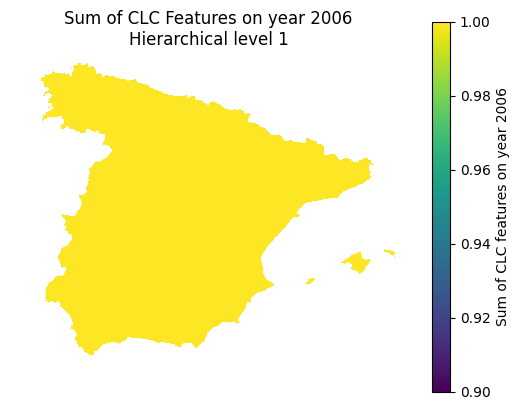

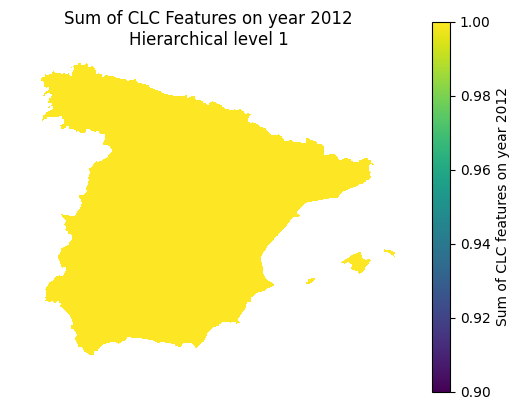

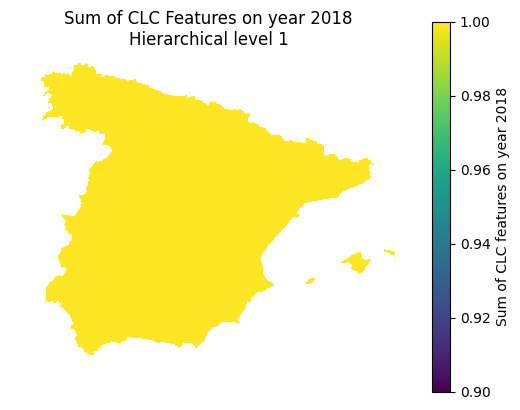

In [11]:
import numpy as np
import matplotlib.pyplot as plt

cases = ["artificial_proportion",
        "agricultural_proportion",
        "forest_and_semi_natural_proportion",
        "wetlands_proportion",
        "waterbody_proportion"]

for year in ["2006", "2012", "2018"]:
    clc_subset = ds[[f"CLC_{year}_{case}" for case in cases]]

    # Clip to valid instances (is_spain == 1)
    clc_subset = clc_subset.where(ds["is_spain"] == 1)


    arrays = []
    for var in clc_subset.data_vars:
        arrays.append(clc_subset[var].values)

    sum_array = np.sum(np.stack(arrays), axis=0)

    plt.imshow(sum_array, cmap='viridis', vmin = 0.9)  # You can use 'gray', 'plasma', etc. too
    plt.colorbar(label=f'Sum of CLC features on year {year}')
    plt.title(f'Sum of CLC Features on year {year}\nHierarchical level 1')
    plt.axis("off")
    plt.show()

#### Aspect

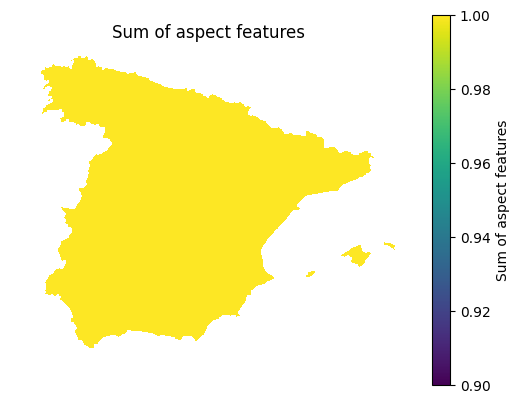

In [12]:
clc_subset = ds[[f"aspect_{i}" for i in range(1,9)] + ["aspect_NODATA"]]

# Clip to valid instances (is_spain == 1)
clc_subset = clc_subset.where(ds["is_spain"] == 1)


arrays = []
for var in clc_subset.data_vars:
    arrays.append(clc_subset[var].values)

sum_array = np.sum(np.stack(arrays), axis=0)

plt.imshow(sum_array, cmap='viridis', vmin = 0.9)  # You can use 'gray', 'plasma', etc. too
plt.colorbar(label=f'Sum of aspect features')
plt.title(f'Sum of aspect features')
plt.axis("off")
plt.show()

## 5. Percentage check

The minimum and maximum values were calculated previously, on a high RAM device (128 GB)

In [13]:
import pickle as pkl
from src.config import OUTPUTS_DIR

with open(OUTPUTS_DIR / "IberFire_minmax.pkl", 'rb') as f:
    minmax_values = pkl.load(f)
    
print(f"SWI_001: min = {minmax_values["SWI_001_min"]}")
print(f"SWI_001: max = {minmax_values["SWI_001_max"]}")
print()
print(f"SWI_005: min = {minmax_values["SWI_005_min"]}")
print(f"SWI_005: max = {minmax_values["SWI_005_max"]}")
print()
print(f"SWI_010: min = {minmax_values["SWI_010_min"]}")
print(f"SWI_010: max = {minmax_values["SWI_010_max"]}")
print()
print(f"SWI_020: min = {minmax_values["SWI_020_min"]}")
print(f"SWI_020: max = {minmax_values["SWI_020_max"]}")



SWI_001: min = 0.0
SWI_001: max = 100.0

SWI_005: min = 0.0
SWI_005: max = 100.0

SWI_010: min = 0.0
SWI_010: max = 100.0

SWI_020: min = 0.0
SWI_020: max = 100.0


## 6. Missing values on spatial-only data

In [14]:
spatial_only_vars = [var for var in ds.data_vars if not "time" in  ds[var].dims]

for var in spatial_only_vars:
    nan_count = ds[var].isnull().sum().item()
    print(f"{var:<45} : {nan_count} NaN values")

x_index                                       : 0 NaN values
y_index                                       : 0 NaN values
is_spain                                      : 0 NaN values
x_coordinate                                  : 0 NaN values
y_coordinate                                  : 0 NaN values
is_sea                                        : 0 NaN values
is_waterbody                                  : 0 NaN values
AutonomousCommunities                         : 0 NaN values
CLC_2006_1                                    : 0 NaN values
CLC_2006_2                                    : 0 NaN values
CLC_2006_3                                    : 0 NaN values
CLC_2006_4                                    : 0 NaN values
CLC_2006_5                                    : 0 NaN values
CLC_2006_6                                    : 0 NaN values
CLC_2006_7                                    : 0 NaN values
CLC_2006_8                                    : 0 NaN values
CLC_2006_9              

#### Missing values on is_fire and is_near_fire 

In [15]:
features = ["is_fire", "is_near_fire"]

for var in features:
    nan_count = ds[var].isnull().sum().item()
    print(f"{var:<15} : {nan_count} NaN values")

is_fire         : 0 NaN values
is_near_fire    : 0 NaN values
